### Creating labeled dataset

In [ ]:
# --- Step 1.1: Import Libraries and Load Your Data ---
import pandas as pd
import numpy as np

# Load the features csv file
features_df = pd.read_csv("../outputs/comprehensive_features.csv")

# Load the cluster assignments csv file
cluster_map_df = pd.read_csv("../outputs/image_cluster_map.csv")


# --- Merge the DataFrames ---
# This combines the two files into a single master table using the 'image_id'
df_merged = pd.merge(features_df, cluster_map_df, on='image_id')


# --- Define and Create Descriptive Labels ---
# This map uses the integer labels from the clustering 
label_map = {
    0: "Uneven Bed / Calloused",
    1: "Smooth Bed, Irregular Edge",
    2: "Deep, Sharp-Edged",
    3: "Superficial & Flat",
    4: "Gradual, Sloping Edge",
    5: "Standard Sharp-Edged",
   -1: "Outlier / Anomaly"
}

# Create a new 'wound_type' column using the map.
df_merged['wound_type'] = df_merged['cluster_label'].map(label_map)


# --- Save Final Labeled Dataset ---
df_merged.to_csv("../outputs/features_with_labels.csv", index=False)

print("Labeled dataset created successfully!")
print("Here are the counts for each wound type:")
print(df_merged['wound_type'].value_counts())

Labeled dataset created successfully!
Here are the counts for each wound type:
wound_type
Standard Sharp-Edged          541
Deep, Sharp-Edged             430
Uneven Bed / Calloused         87
Gradual, Sloping Edge          62
Superficial & Flat             28
Smooth Bed, Irregular Edge     20
Outlier / Anomaly               1
Name: count, dtype: int64


Build and Evaluate Predictive Model


Training the Random Forest model...
Training complete.

Overall Model Accuracy: 0.8974

Classification Report:
                            precision    recall  f1-score   support

         Deep, Sharp-Edged       0.94      0.92      0.93        86
     Gradual, Sloping Edge       1.00      0.42      0.59        12
Smooth Bed, Irregular Edge       1.00      1.00      1.00         4
      Standard Sharp-Edged       0.87      0.95      0.91       108
        Superficial & Flat       0.50      0.17      0.25         6
    Uneven Bed / Calloused       0.86      1.00      0.92        18

                  accuracy                           0.90       234
                 macro avg       0.86      0.74      0.77       234
              weighted avg       0.90      0.90      0.89       234


Confusion Matrix:


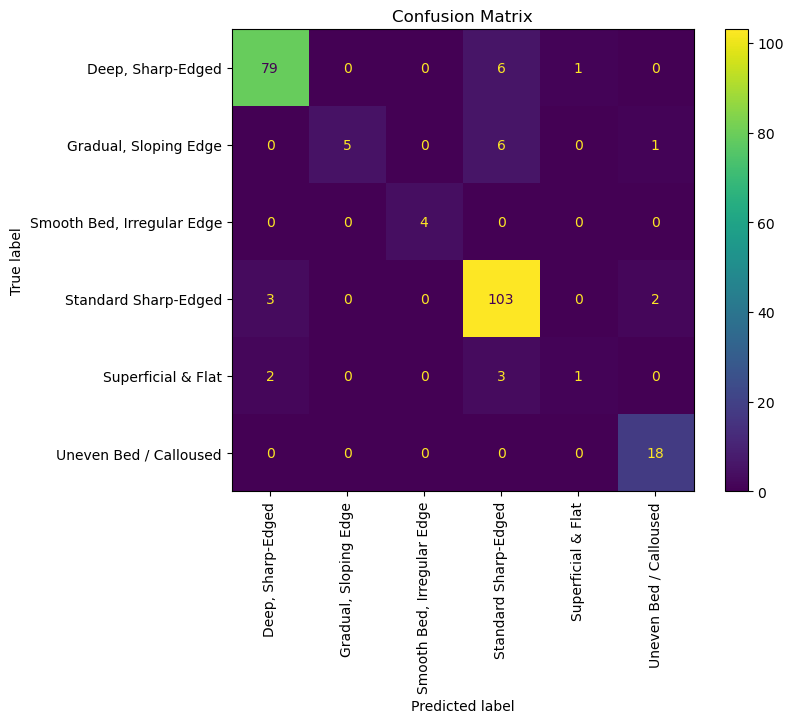

In [4]:
# --- Prepare for Supervised Learning ---
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Use the merged dataframe from the previous step
# filter out the 'Outliers' 
df_final = df_merged[df_merged['wound_type'] != 'Outlier / Anomaly'].copy()

# target 'y' is the descriptive wound type
y = df_final['wound_type']

# features 'X' are all numerical columns. We drop the identifiers.
X = df_final.drop(columns=['image_id', 'cluster_label', 'wound_type']) 


# ---Split the Data ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# --- Train the Model ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
print("\nTraining the Random Forest model...")
rf_model.fit(X_train, y_train)
print("Training complete.")


# --- Evaluate Model Performance ---
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Model Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, ax=ax, xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

### Analyze Feature Importance


Top 10 Most Important Features:
           feature  importance
7      edge_offset    0.162992
4   edge_amplitude    0.129361
18       edge_mean    0.082157
14        bed_mean    0.079270
6    edge_midpoint    0.065322
1    bed_intercept    0.046529
2           bed_r2    0.044716
24       skin_skew    0.032490
5   edge_steepness    0.030130
25   skin_kurtosis    0.029436


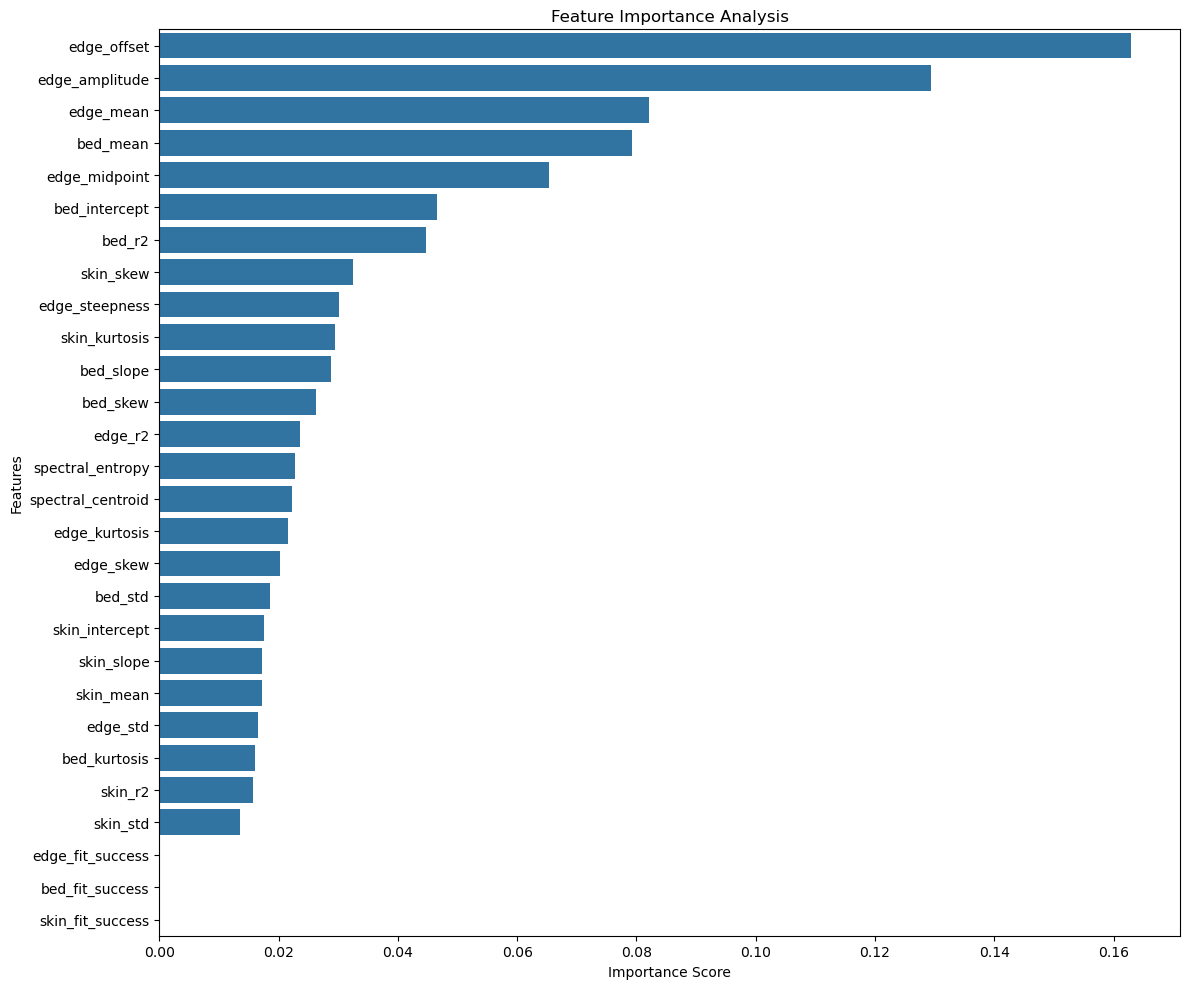

In [3]:
import seaborn as sns

importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10))

plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importance Analysis')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()